In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

df1 = pd.read_csv("/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed/behaviour_detection.csv")
df1["condition"] = 'grouped'

df2 = pd.read_csv("/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/socially-isolated/behaviour_detection.csv")
df2["condition"] = 'isolated'


df = pd.concat([df1, df2], ignore_index=True)

print(df.columns)



Index(['track_id', 'frame', 'instance_score', 'x_head', 'y_head', 'score_head',
       'x_body', 'y_body', 'score_body', 'x_tail', 'y_tail', 'score_tail',
       'within_walls', 'vector_tail_head_x', 'vector_tail_head_y',
       'vector_head_tail_x', 'vector_head_tail_y', 'prev_vector_x',
       'prev_vector_y', 'align_tail_head', 'align_head_tail', 'flipped',
       'x_head_corrected', 'y_head_corrected', 'x_tail_corrected',
       'y_tail_corrected', 'flipped_corrected', 'checked_window',
       'align_tail_head_corrected', 'align_head_tail_corrected',
       'tail_dist_noflip', 'tail_dist_flip', 'align_difference', 'head_speed',
       'tail_speed', 'body_speed', 'head_tail_speed_diff', 'head_acceleration',
       'tail_acceleration', 'body_acceleration', 'tail_head_direction_angle',
       'tail_head_turn_rate', 'bend_angle', 'bend_magnitude',
       'head_lateral_displacement', 'head_lateral_magnitude', 'alignment',
       'tail_head_length', 'tail_body_length', 'body_head_length'

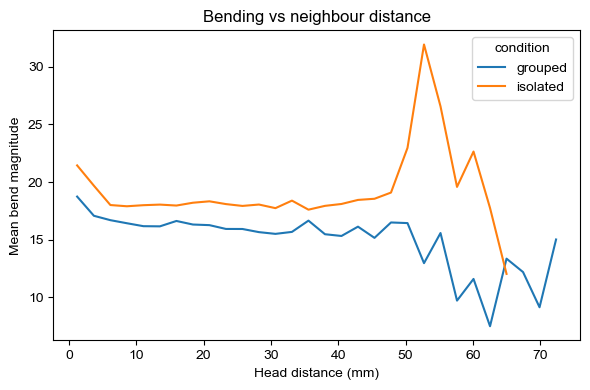

In [39]:
df_plot = df[
    (df["head_distance"].notna()) &
    (df["bend_magnitude"].notna())
].copy()

# bin distances
df_plot["distance_bin"] = pd.cut(df_plot["head_distance"], bins=30)

# get bin centres
df_plot["distance_mid"] = df_plot["distance_bin"].apply(lambda x: x.mid)

binned = (
    df_plot.groupby(["distance_mid", "condition"])["bend_magnitude"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))

sns.lineplot(
    data=binned,
    x="distance_mid",
    y="bend_magnitude",
    hue="condition"
)

plt.ylabel("Mean bend magnitude")
plt.xlabel("Head distance (mm)")
plt.title("Bending vs neighbour distance")

plt.tight_layout()
plt.show()

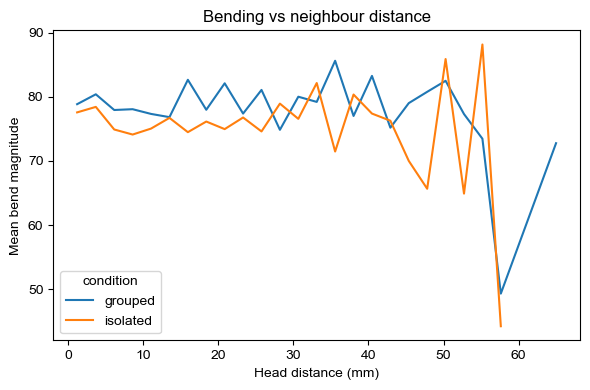

In [40]:
df_plot = df[
    (df["head_distance"].notna()) &
    (df["bend_magnitude"].notna())
].copy()

# bin distances
df_plot["distance_bin"] = pd.cut(df_plot["head_distance"], bins=30)

# get bin centres
df_plot["distance_mid"] = df_plot["distance_bin"].apply(lambda x: x.mid)

df_plot = df_plot[df_plot['behaviour'] == 'sharp_turn']

binned = (
    df_plot.groupby(["distance_mid", "condition"])["bend_magnitude"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))

sns.lineplot(
    data=binned,
    x="distance_mid",
    y="bend_magnitude",
    hue="condition"
)

plt.ylabel("Mean bend magnitude")
plt.xlabel("Head distance (mm)")
plt.title("Bending vs neighbour distance")

plt.tight_layout()
plt.show()

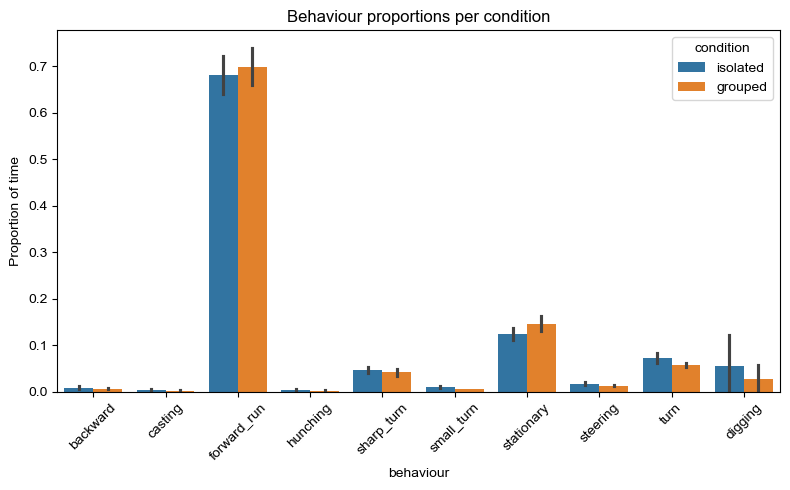

In [19]:
# total frames per video
total_frames = (
    df.groupby(["file"])
    .size()
    .reset_index(name="total_frames")
)

# frames per behaviour per video
behaviour_frames = (
    df.groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_frames")
)

# merge + compute proportion
behaviour_prop = behaviour_frames.merge(total_frames, on="file")
behaviour_prop["proportion"] = behaviour_prop["n_frames"] / behaviour_prop["total_frames"]


plt.figure(figsize=(8,5))

sns.barplot(
    data=behaviour_prop,
    x="behaviour",
    y="proportion",
    hue="condition",
    errorbar="sd"
)

plt.ylim(0,None)
plt.xticks(rotation=45)
plt.ylabel("Proportion of time")
plt.title("Behaviour proportions per condition")

plt.tight_layout()
plt.show()

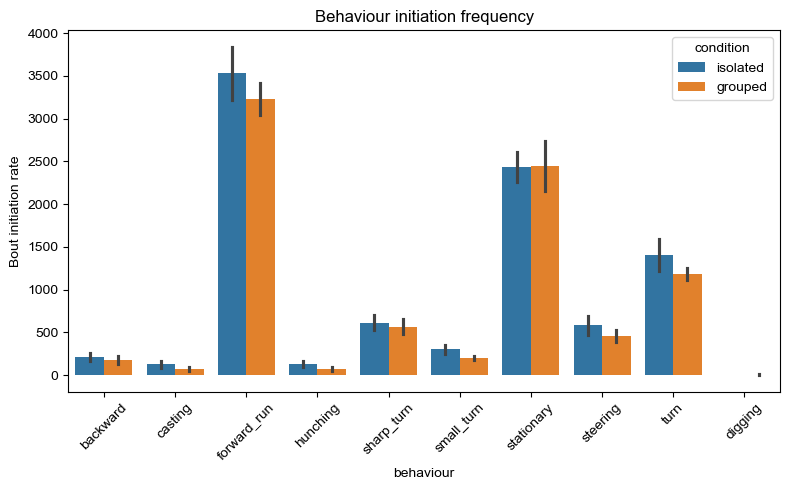

In [20]:
df = df.sort_values(["file", "track_id", "frame"]).copy()

df["prev_behaviour"] = df.groupby(["file", "track_id"])["behaviour"].shift()

df["is_initiation"] = df["behaviour"] != df["prev_behaviour"]

bout_counts = (
    df[df["is_initiation"]]
    .groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_bouts")
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=bout_counts,
    x="behaviour",
    y="n_bouts",
    hue="condition",
    errorbar="sd"
)

plt.xticks(rotation=45)
plt.ylabel("Bout initiation rate")
plt.title("Behaviour initiation frequency")

plt.tight_layout()
plt.show()

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_18697/3021820091.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


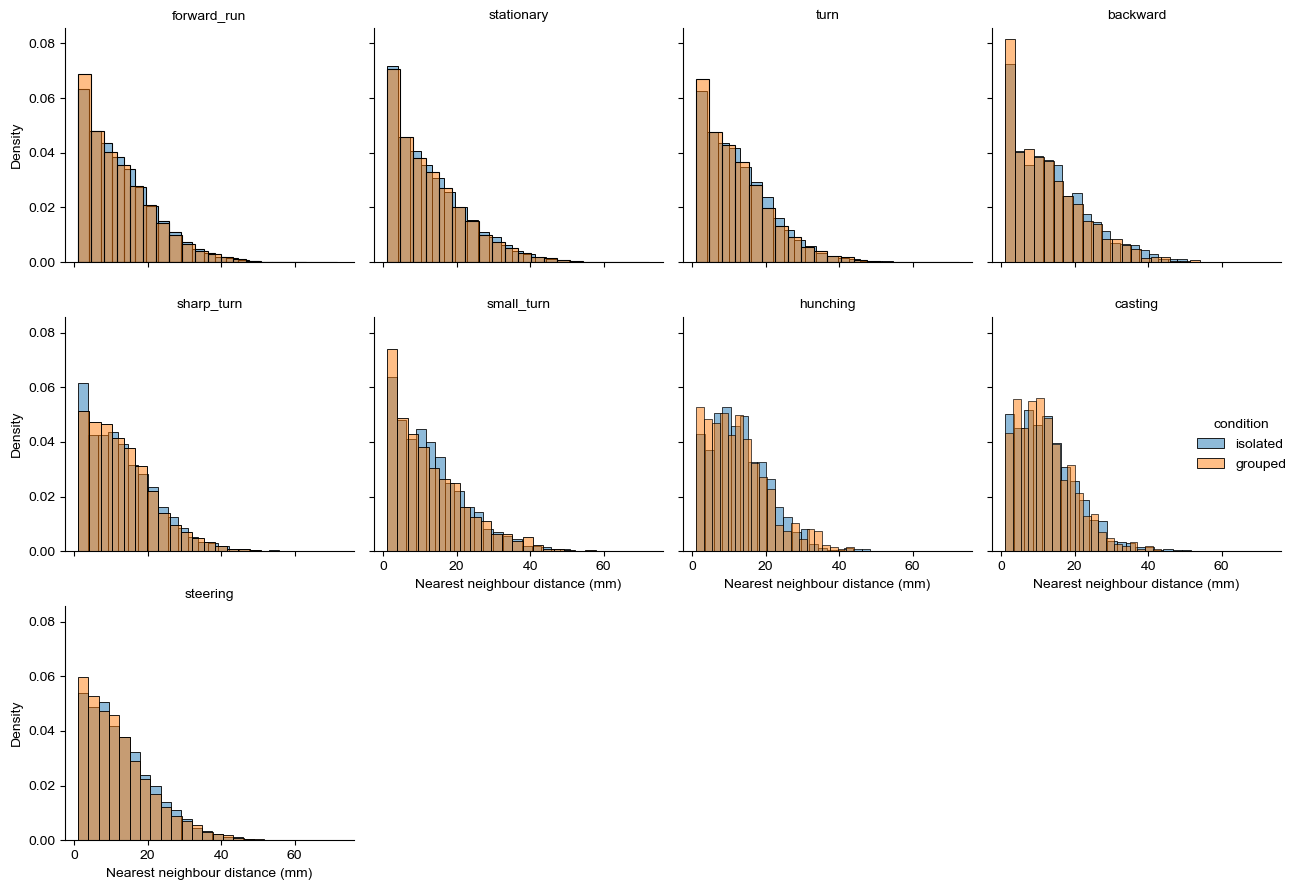

In [29]:


init_df = df[df["is_initiation"]].copy()
init_df = init_df[init_df["closest_node_node_distance"].notna()]
init_df = init_df[
    (init_df["closest_node_node_distance"].notna()) &
    (init_df["closest_node_node_distance"] >= 1)
]
init_df = init_df[init_df["behaviour"] != "digging"]  # optional

g = sns.FacetGrid(
    init_df,
    col="behaviour",
    col_wrap=4,
    hue="condition",
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.histplot,
    x="closest_node_node_distance",
    bins=20,
    stat="density",     # so shapes comparable
    common_norm=False,  # IMPORTANT for hue comparison
    alpha=0.5
)

g.add_legend()

g.set_axis_labels("Nearest neighbour distance (mm)", "Density")
g.set_titles("{col_name}")

plt.tight_layout()
plt.show()



/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_18697/3471907387.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


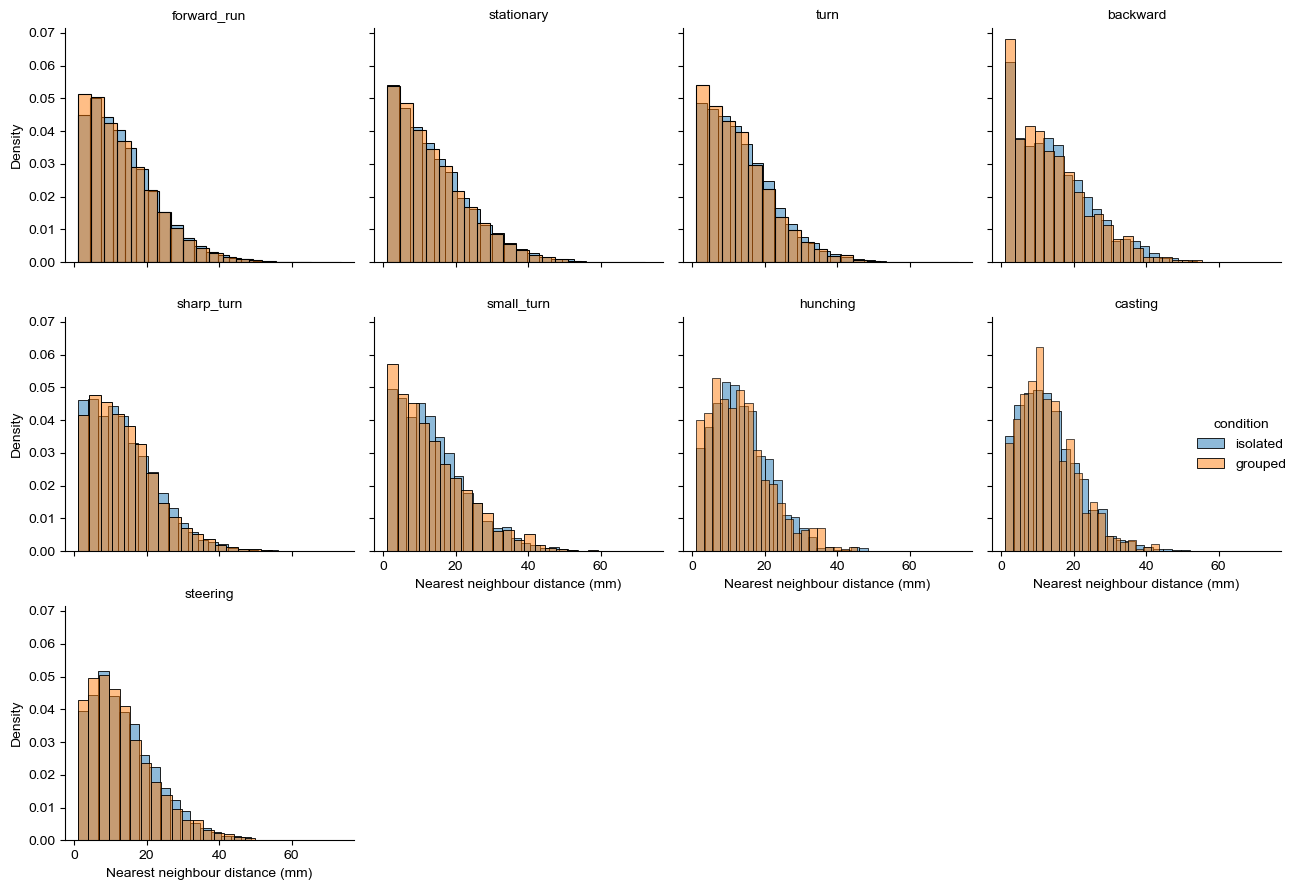

In [34]:

init_df = df[df["is_initiation"]].copy()
init_df = init_df[init_df["closest_node_node_distance"].notna()]
init_df = init_df[
    (init_df["closest_node_node_distance"].notna()) &
    (init_df["closest_node_node_distance"] >= 1)
]
init_df = init_df[init_df["behaviour"] != "digging"]  # optional

g = sns.FacetGrid(
    init_df,
    col="behaviour",
    col_wrap=4,
    hue="condition",
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.histplot,
    x="head_distance",
    bins=20,
    stat="density",     # so shapes comparable
    common_norm=False,  # IMPORTANT for hue comparison
    alpha=0.5
)

g.add_legend()

g.set_axis_labels("Nearest neighbour distance (mm)", "Density")
g.set_titles("{col_name}")

plt.tight_layout()
plt.show()

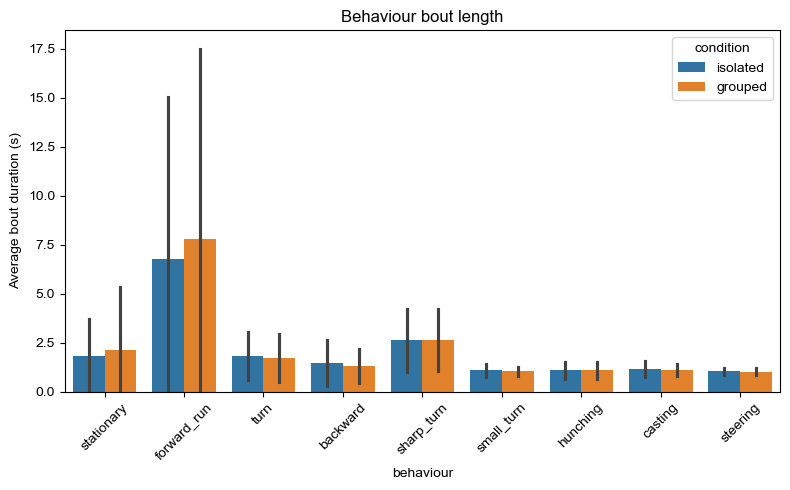

In [23]:
df["new_bout"] = df["behaviour"] != df["prev_behaviour"]

df["bout_id"] = df.groupby(["file", "track_id"])["new_bout"].cumsum()

bouts = (
    df.groupby(["file", "condition", "track_id", "bout_id", "behaviour"])
    .agg(
        start_frame=("frame", "min"),
        end_frame=("frame", "max"),
        n_frames=("frame", "count")
    )
    .reset_index()
)

bouts_no_digging = bouts[bouts["behaviour"] != "digging"].copy()

plt.figure(figsize=(8,5))

sns.barplot(
    data=bouts_no_digging,
    x="behaviour",
    y="n_frames",
    hue="condition",
    errorbar="sd"
)

plt.ylim(0,None )
plt.xticks(rotation=45)
plt.ylabel("Average bout duration (s)")
plt.title("Behaviour bout length")

plt.tight_layout()
plt.show()

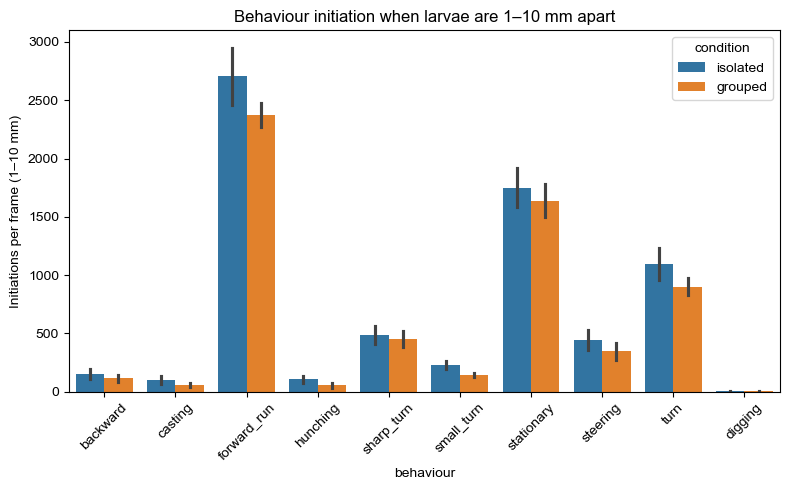

In [33]:
df_close = df[
    (df["closest_node_node_distance"].notna()) &
    (df["closest_node_node_distance"] >= 1) &
    (df["closest_node_node_distance"] <= 20)
].copy()

df_close = df_close.sort_values(["file", "track_id", "frame"])

df_close["prev_behaviour"] = (
    df_close.groupby(["file", "track_id"])["behaviour"].shift()
)

df_close["is_initiation"] = (
    df_close["prev_behaviour"].notna() &
    (df_close["behaviour"] != df_close["prev_behaviour"])
)

bout_counts = (
    df_close[df_close["is_initiation"]]
    .groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_bouts")
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=bout_counts,
    x="behaviour",
    y="n_bouts",
    hue="condition",
    errorbar="sd"
)

plt.xticks(rotation=45)
plt.ylabel("Initiations per frame (1–10 mm)")
plt.title("Behaviour initiation when larvae are 1–10 mm apart")

plt.tight_layout()
plt.show()

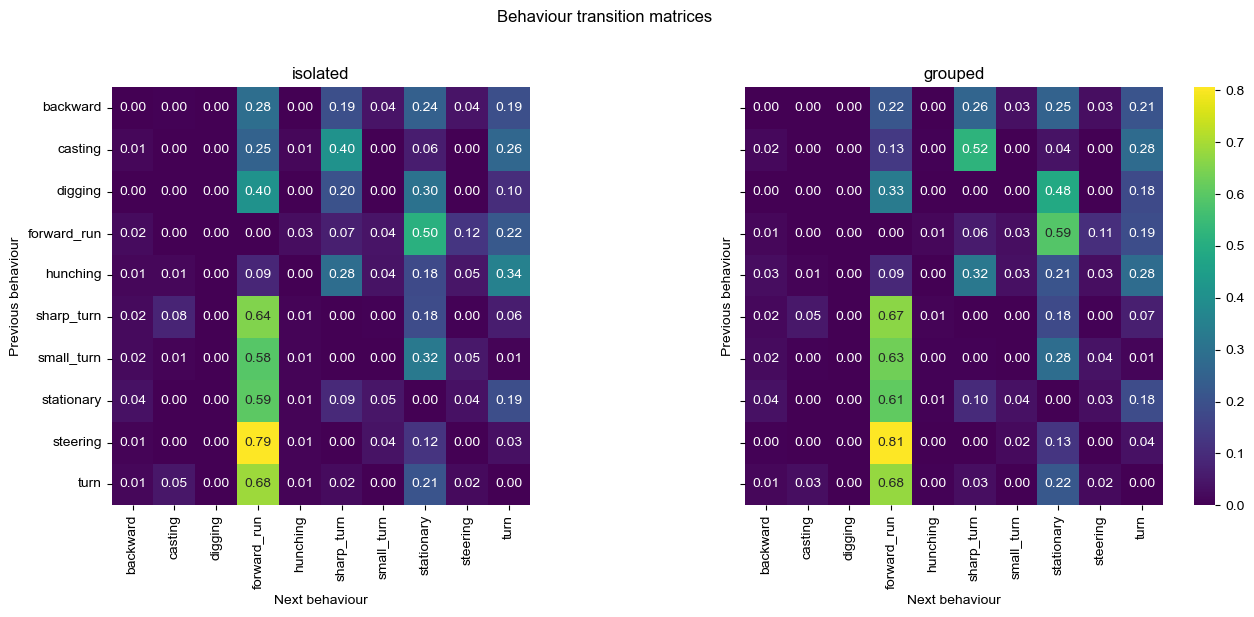

In [42]:
df_trans = df.sort_values(["file", "track_id", "frame"]).copy()

df_trans["prev_behaviour"] = (
    df_trans.groupby(["file", "track_id"])["behaviour"].shift()
)

df_trans = df_trans[
    df_trans["prev_behaviour"].notna() &
    (df_trans["behaviour"] != df_trans["prev_behaviour"])
].copy()

conditions = ["isolated", "grouped"]  # enforce order

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, condition in zip(axes, conditions):

    mat = pd.crosstab(
        df_trans.loc[df_trans["condition"] == condition, "prev_behaviour"],
        df_trans.loc[df_trans["condition"] == condition, "behaviour"],
        normalize="index"
    )

    sns.heatmap(
        mat,
        ax=ax,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        cbar=ax == axes[-1],  # only show one colorbar
        square=True
    )

    ax.set_title(condition)
    ax.set_xlabel("Next behaviour")
    ax.set_ylabel("Previous behaviour")

plt.suptitle("Behaviour transition matrices", y=1.02)
plt.tight_layout()
plt.show()

mb only within 5mm and facing other larvae idk?

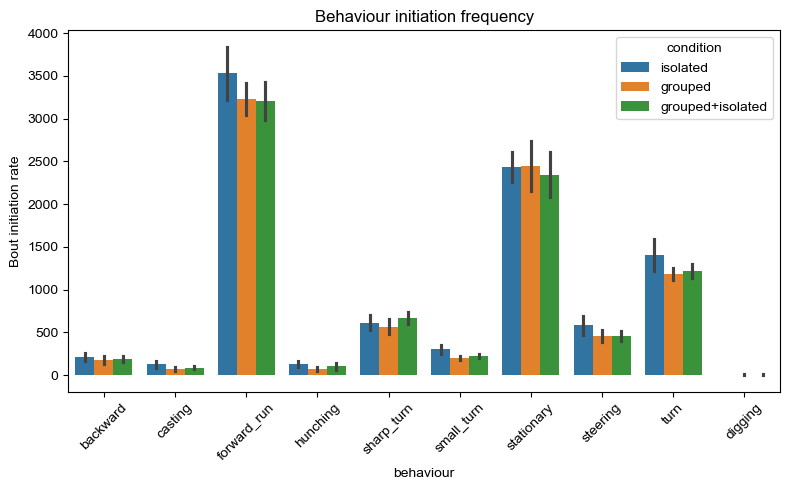

In [44]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

df1 = pd.read_csv("/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed/behaviour_detection.csv")
df1["condition"] = 'grouped'

df2 = pd.read_csv("/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/socially-isolated/behaviour_detection.csv")
df2["condition"] = 'isolated'

df_ghsi = pd.read_csv("/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/grouped+isolated/behaviour_detection.csv")
df_ghsi["condition"] = 'grouped+isolated'

df = pd.concat([df1, df2, df_ghsi], ignore_index=True)


df = df.sort_values(["file", "track_id", "frame"]).copy()

df["prev_behaviour"] = df.groupby(["file", "track_id"])["behaviour"].shift()

df["is_initiation"] = df["behaviour"] != df["prev_behaviour"]

bout_counts = (
    df[df["is_initiation"]]
    .groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_bouts")
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=bout_counts,
    x="behaviour",
    y="n_bouts",
    hue="condition",
    errorbar="sd"
)

plt.xticks(rotation=45)
plt.ylabel("Bout initiation rate")
plt.title("Behaviour initiation frequency")

plt.tight_layout()
plt.show()





In [ ]:
init_df = df[df["is_initiation"]].copy()
init_df = init_df[init_df["closest_node_node_distance"].notna()]
init_df = init_df[
    (init_df["closest_node_node_distance"].notna()) &
    (init_df["closest_node_node_distance"] >= 1)
]
init_df = init_df[init_df["behaviour"] != "digging"]  # optional

g = sns.FacetGrid(
    init_df,
    col="behaviour",
    col_wrap=4,
    hue="condition",
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.histplot,
    x="closest_node_node_distance",
    bins=20,
    stat="density",     # so shapes comparable
    common_norm=False,  # IMPORTANT for hue comparison
    alpha=0.4
)

g.add_legend()

g.set_axis_labels("Nearest neighbour distance (mm)", "Density")
g.set_titles("{col_name}")

plt.tight_layout()
plt.show()